
# 🚀 Day 26 — AdaBoost (Adaptive Boosting)

## Deep Theory + Visual Learning Notebook

### Topics Covered
- Ensemble Learning
- Boosting vs Bagging
- AdaBoost Core Concept
- Decision Stumps
- Weight Update Mechanism
- Alpha Calculation
- Final Weighted Voting
- Advantages & Limitations
- BFSI Use Cases
- Hyperparameters
- sklearn Implementation
- Mini Project
- Interview Questions



# 🌳 1. Introduction to Ensemble Learning

Machine Learning models often suffer from:

- **High Bias** → Model is too simple
- **High Variance** → Model overfits data

Ensemble learning solves this by combining multiple models.

---

## 🎯 Core Idea

Instead of relying on one model:

👉 Combine many weak models  
👉 Create one strong intelligent system

---

# 🔥 Types of Ensemble Methods

| Method | Core Idea |
|---|---|
| Bagging | Parallel learning |
| Boosting | Sequential learning |
| Stacking | Meta-learning |

---

# 🏦 Real-world BFSI Examples

- Fraud Detection
- Credit Risk Prediction
- Loan Default Prediction
- Insurance Risk Analysis



# ⚡ 2. What is Boosting?

Boosting trains models **sequentially**.

Each new model:
✅ Learns from previous mistakes  
✅ Focuses more on difficult observations

---

# 🔁 Sequential Error Correction

Model 1 → mistakes identified  
⬇  
Model 2 focuses on mistakes  
⬇  
Model 3 focuses on remaining errors  
⬇  
Final strong ensemble model

---

# 🎯 Goal of Boosting

Reduce:
- Bias
- Underfitting




# 🚀 3. AdaBoost — Adaptive Boosting

AdaBoost was one of the first successful boosting algorithms.

---

# 🧠 Core Idea

👉 Give more importance to misclassified points  
👉 Force next model to focus on difficult cases

---

# 🔥 Why called "Adaptive"?

Because:
- Sample weights keep changing
- Model adapts after every iteration

---

# 💡 Final Model

Final prediction = weighted combination of weak learners



# 🪵 4. Weak Learners — Decision Stumps

AdaBoost usually uses:

# 🌳 Decision Stumps

A stump is:
- A tree with only 1 split
- Very weak individually
- Powerful when combined

---

# 📌 Why Weak Learners?

AdaBoost works best when:
- Each learner is slightly better than random guessing

---

# 🎯 Key Insight

Many weak learners  
➡ Combined together  
➡ Create a strong learner



# 📉 5. Weighted Error Formula

AdaBoost calculates weighted error:

$$
\text{Error} = \sum_{i=1}^{N} w_i \cdot I(y_i \neq \hat{y}_i)
$$

Where:
- \( w_i \) = sample weight
- \( I \) = indicator function
- Wrong predictions contribute more

---

# 🧠 Alpha (Model Importance)

$$
\alpha = \frac{1}{2}\ln\left(\frac{1-\text{Error}}{\text{Error}}\right)
$$

### Interpretation

| Error | Alpha |
|---|---|
| Low Error | High Alpha |
| High Error | Low Alpha |

---

# ⚖️ Weight Update Rule

$$
w_i \leftarrow w_i e^{-\alpha y_i h(x_i)}
$$

Misclassified points receive higher weight.



# 🔁 6. AdaBoost Training Flow

## Step-by-Step Process

### Step 1
Initialize equal weights.

### Step 2
Train first decision stump.

### Step 3
Calculate weighted error.

### Step 4
Calculate alpha (importance).

### Step 5
Increase weights of mistakes.

### Step 6
Train next stump on updated data.

### Step 7
Combine all models using weighted voting.

---

# 🎯 Final Prediction

Strong learners are created from:
- Weighted weak learners
- Sequential learning



# ✅ 7. Advantages of AdaBoost

## 🚀 Strengths

- Excellent performance on structured data
- Reduces bias effectively
- Converts weak learners into strong learners
- Often achieves high accuracy
- Works well in classification tasks

---

# ⚠️ 8. Limitations of AdaBoost

## Challenges

- Sensitive to noisy data
- Outliers can dominate learning
- Sequential training is slower
- Hard to parallelize



# ⚔️ 9. AdaBoost vs Random Forest

| Feature | AdaBoost | Random Forest |
|---|---|---|
| Learning Style | Sequential | Parallel |
| Focus | Reduce Bias | Reduce Variance |
| Weak Learners | Decision Stumps | Deep Trees |
| Noise Sensitivity | High | Low |
| Speed | Slower | Faster |
| Parallelization | Difficult | Easy |



# 🏦 10. BFSI Business Use Cases

## Fraud Detection
Detect suspicious transactions using boosting patterns.

## Loan Default Prediction
Identify risky borrowers using ensemble learning.

## Insurance Claim Risk
Predict high-risk claims using multiple weak learners.

## Credit Card Approval
Improve classification accuracy for approvals.



# 💻 11. Hands-on Implementation

We now implement AdaBoost using:
- sklearn
- Decision Stumps
- Synthetic Classification Dataset


In [2]:

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# Create dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dataset ready")


Dataset ready


In [3]:

# Decision Stump
stump = DecisionTreeClassifier(max_depth=1)

# AdaBoost Model
ada = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Train
ada.fit(X_train, y_train)

# Predict
y_pred = ada.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)


Accuracy: 0.74


In [4]:

# Classification Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.64      0.73       113
           1       0.65      0.87      0.75        87

    accuracy                           0.74       200
   macro avg       0.76      0.76      0.74       200
weighted avg       0.77      0.74      0.74       200



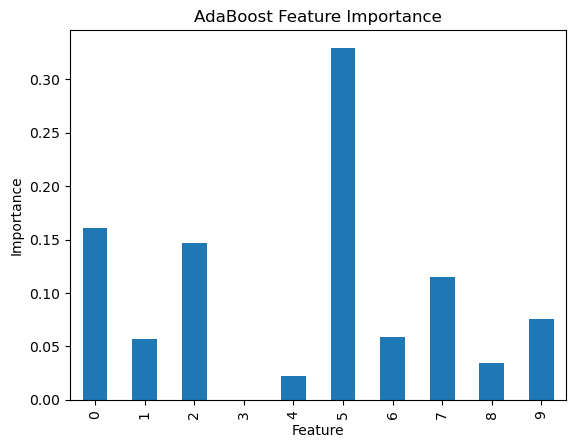

In [5]:

# Feature Importance Visualization

importance = pd.Series(
    ada.feature_importances_
)

importance.plot(kind='bar')

plt.title("AdaBoost Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()



# 🎛️ 12. Hyperparameters Deep Dive

| Hyperparameter | Meaning |
|---|---|
| n_estimators | Number of weak learners |
| learning_rate | Contribution of each learner |
| estimator | Base weak learner |
| max_depth | Complexity of stump/tree |

---

# 🎯 Important Tradeoff

More estimators:
- Better learning
- Higher computation



# 🧪 13. Mini Project — Fraud Detection System

## 🎯 Objective

Compare:
- Logistic Regression
- Random Forest
- AdaBoost

---

# Tasks

✅ Train all models  
✅ Compare Accuracy  
✅ Compare Precision & Recall  
✅ Plot Feature Importance  
✅ Analyze False Positives  

---

# 🏦 Business Insight

In fraud detection:
- Missing fraud is extremely costly
- Boosting often improves recall



# 🎓 14. Interview Questions

## Q1. Why use decision stumps in AdaBoost?
Because AdaBoost combines many weak learners effectively.

---

## Q2. Why is AdaBoost sensitive to noise?
Because misclassified noisy points get higher weights repeatedly.

---

## Q3. Difference between AdaBoost and Gradient Boosting?
AdaBoost adjusts sample weights.  
Gradient Boosting learns residual errors.

---

## Q4. Why does boosting reduce bias?
Sequential learning continuously corrects mistakes.



# 📝 15. Final Revision Cheatsheet

## 🚀 AdaBoost Quick Summary

✅ Sequential learning  
✅ Focuses on mistakes  
✅ Uses weak learners  
✅ Weighted voting ensemble  
✅ Reduces bias  
⚠ Sensitive to noise  

---

# 💡 Final Insight

> Bagging reduces variance.  
> Boosting reduces bias.  
> AdaBoost made ensemble learning practical and powerful.
